<a href="https://colab.research.google.com/github/richardmendonca-senai/dataview/blob/main/dataview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import os

def gerar_dataset_vendas(n_registros=150, seed=42):
    """Gera um dataset sintético de vendas com dados propositalmente sujos,
    incluindo valores nulos, strings sujas, datas inválidas e outliers."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Teclado', 'Mouse']
    precos = { 'Notebook': 3500, 'Smartphone': 2200, 'Tablet': 1800, 'Monitor': 1200, 'Teclado': 250, 'Mouse': 120 }
    categorias = { "Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares", "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos" }
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto]
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None          # valor nulo
        if random.random() < 0.04:
            preco = None               # valor nulo
        if random.random() < 0.03:
            produto = "  " + produto   # espaço extra (string suja)

        # LINHA CORRIGIDA: Alinhada para ficar dentro do laço 'for'
        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"

        # LINHA CORRIGIDA: Alinhada com as outras ações do laço 'for'
        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

# Gerar e salvar
df_bruto = gerar_dataset_vendas()
os.makedirs('data/raw', exist_ok=True) # Adicionado para garantir que o diretório exista
df_bruto.to_csv("data/raw/vendas.csv", index=False)
print(f"Dataset gerado com {len(df_bruto)} registros.")
print(df_bruto.head())


Dataset gerado com 150 registros.
   id_venda     data_venda      cliente   produto     categoria        regiao  \
0         1     2024-01-13  Cliente_024     Mouse   Periféricos         Norte   
1         2     2024-08-04  Cliente_018  Notebook  Computadores           Sul   
2         3  DATA INVALIDA  Cliente_026     Mouse   Periféricos           Sul   
3         4     2024-06-23  Cliente_013     Mouse   Periféricos       Sudeste   
4         5     2024-11-05  Cliente_030    Tablet     Celulares  Centro-Oeste   

   quantidade  preco_unitario  
0         2.0           120.0  
1         NaN          3500.0  
2         9.0           120.0  
3         7.0           120.0  
4         6.0          1800.0  


In [3]:
# Função original fornecida no enunciado do requisito
def inspecionar_dados(df):
    """Exibe informações básicas do DataFrame."""
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    print(f"\nEstatísticas descritivas:\n{df.describe()}")
    return df.describe(include="all")

# --- EXECUÇÃO DO REQUISITO RF02 ---
# Carrega o dataset que você gerou e salvou no RF01
df_para_analise = pd.read_csv("data/raw/vendas.csv")

# Executa a inspeção passando o DataFrame carregado
resumo_completo = inspecionar_dados(df_para_analise)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:
   id_venda     data_venda      cliente   produto     categoria        regiao  \
0         1     2024-01-13  Cliente_024     Mouse   Periféricos         Norte   
1         2     2024-08-04  Cliente_018  Notebook  Computadores           Sul   
2         3  DATA INVALIDA  Cliente_026     Mouse   Periféricos           Sul   
3         4     2024-06-23  Cliente_013     Mous

In [16]:
import re
import os
import pandas as pd # Garantindo que o pandas está aqui caso precise

# LIMPEZA COM EXPRESSÕES REGULARES (módulo re)
# re.sub(padrão, substituto, string) substitui todas as ocorrências
# do padrão pela string substituta.
# r"\s+" é um padrão regex que significa "um ou mais espaços em branco"
# (incluindo espaços, tabs e quebras de linha).
# -------------------------------------------------------------------
def limpar_strings_regex(df, colunas):
    """ Usa expressões regulares para normalizar colunas de texto: - Colapsa múltiplos espaços internos em um único espaço (re.sub) - Remove espaços nas pontas da string (.strip()) - Preserva células nulas sem lançar erro (pd.notna) """
    df = df.copy() # Não modifica o DataFrame original
    for col in colunas:
        df[col] = df[col].apply(
# pd.notna(s): verifica se o valor NÃO é nulo antes de processar
# re.sub(r"\s+", " ", str(s)): substitui sequências de espaços por um único espaço
# .strip(): remove espaços residuais nas pontas
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s)
    return df

def limpar_dados(df):
    """ Limpa o DataFrame de vendas em quatro etapas: 1. Normaliza strings com regex (espaços extras) 2. Converte datas e remove registros com datas inválidas 3. Remove linhas com valores nulos em colunas obrigatórias 4. Garante os tipos numéricos corretos Retorna: (df_limpo, relatorio) — o relatório documenta o impacto de cada etapa. """
    df = df.copy()
    n_inicial = len(df)
    relatorio = {}
    # --- Etapa 1: limpeza de strings com regex ---
    # select_dtypes("object") seleciona apenas colunas de texto
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)

    # --- Etapa 2: conversão de datas ---
    # errors="coerce" transforma valores inválidos (ex: "31/02/2024") em NaT em vez de lançar um erro — depois removemos essas linhas com dropna
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    relatorio["datas_invalidas_removidas"] = int(df["data_venda"].isnull().sum())
    df = df.dropna(subset=["data_venda"])

    # --- Etapa 3: remoção de nulos em colunas obrigatórias ---
    # Uma linha sem quantidade ou preço não pode contribuir para nenhuma métrica; # por isso optamos por remover (em vez de imputar) esses registros.
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # --- Etapa 4: garantia de tipos numéricos --- # Após o dropna, os valores existentes podem ainda estar como float/object; # forçamos int para quantidade e float para preço.
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # --- Relatório final ---
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df) # soma de todas as remoções
    print("=== RELATORIO DE LIMPEZA ===")
    for k, v in relatorio.items():
        print(f" {k}: {v}")

    return df, relatorio

# EXECUÇÃO: limpar o dataset bruto e salvar como versão v1 (com outliers)
# Nesta versão os outliers são MANTIDOS — eles serão tratados na RF04.
df_v1, relatorio = limpar_dados(df_bruto)

os.makedirs("data/processed/v1_com_outliers", exist_ok=True) # cria o diretório se não existir
df_v1.to_csv("data/processed/v1_com_outliers/vendas_v1.csv", index=False)

print("\nv1 salva em data/processed/v1_com_outliers/")
df_v1.head()

=== RELATORIO DE LIMPEZA ===
 datas_invalidas_removidas: 4
 linhas_nulas_removidas: 6
 registros_iniciais: 150
 registros_finais: 140
 registros_removidos_total: 10

v1 salva em data/processed/v1_com_outliers/


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0
5,6,2024-05-30,Cliente_023,Notebook,Computadores,Sudeste,9,3500.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0


In [17]:
import os
import pandas as pd

# ===================================================================
# RF04 – DETECTAR E TRATAR OUTLIERS
# ===================================================================

def tratar_outliers(df, colunas, fator=1.5, metodo='remover'):
    """
    Trata outliers de colunas numéricas usando o Intervalo Interquartil (IQR).

    Parâmetros:
      colunas : lista de colunas numéricas a verificar
      fator   : multiplicador do IQR para definir os limites (padrão=1.5)
      metodo  : 'remover' exclui as linhas com outliers;
                'limitar' aplica winsorização (substitui pelo limite)

    Retorna o DataFrame tratado sem modificar o original (usa .copy()).
    """
    df = df.copy()  # garante que df_v1 não seja alterado fora da função
    for col in colunas:
        # Q1 = 25% dos dados estão abaixo desse valor
        # Q3 = 75% dos dados estão abaixo desse valor
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1  # largura do intervalo central (50% dos dados)

        lim_inf = q1 - fator * iqr  # abaixo disso = outlier inferior
        lim_sup = q3 + fator * iqr  # acima disso  = outlier superior

        # Conta quantas linhas estão fora dos limites (| = OR lógico)
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f'  {col}: {n_out} outliers detectados '
              f'(lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})')

        if metodo == 'remover':
            # Mantém apenas as linhas dentro dos limites
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            # Winsorização: em vez de remover, "apara" os valores extremos
            # pelo limite — nenhuma linha é perdida, só os valores mudam.
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

    return df


# --- GERAÇÃO DA v2: MESMA BASE DA v1, COM OUTLIERS TRATADOS ---

# Cópia temporária para calcular receita_total sem alterar df_v1
df_v1_tmp = df_v1.copy()
df_v1_tmp["receita_total"] = df_v1_tmp["quantidade"] * df_v1_tmp["preco_unitario"]

# Detecta e remove outliers em quantidade e receita_total
df_v2 = tratar_outliers(
    df_v1_tmp,
    colunas=["quantidade", "receita_total"],
    metodo='remover'
)

# Remove a coluna temporária: ela será recriada no RF05 sobre df_v2 limpo
df_v2 = df_v2.drop(columns=["receita_total"])

# Comparativo de linhas para confirmar quantos outliers foram removidos
print(f"\nv1 = {len(df_v1)} linhas (com outliers)")
print(f"v2 = {len(df_v2)} linhas (outliers removidos)")
print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")

# Salvando a versão v2 no diretório correto
os.makedirs("data/processed/v2_outliers_tratado", exist_ok=True)
df_v2.to_csv("data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)
print("\nv2 salva em data/processed/v2_outliers_tratado/")

  quantidade: 0 outliers detectados (lim_inf=-4.50, lim_sup=15.50)
  receita_total: 6 outliers detectados (lim_inf=-14006.25, lim_sup=26643.75)

v1 = 140 linhas (com outliers)
v2 = 134 linhas (outliers removidos)
Diferença = 6 linhas removidas

v2 salva em data/processed/v2_outliers_tratado/


In [18]:
import numpy as np
import pandas as pd

# ===================================================================
# RF05 – CRIAR COLUNAS DERIVADAS COM TRANSFORMAÇÕES
# ===================================================================

def criar_colunas_derivadas(df):
    """
    Cria colunas calculadas a partir do dataset limpo:
      - receita_total     : valor total da linha de venda (quantidade × preço)
      - mes / trimestre / ano : componentes extraídos da data
      - faixa_receita_item : classificação do valor de cada venda (np.select)

    Nota: receita_total foi calculada temporariamente no RF04 apenas para
    detecção de outliers e depois descartada. Aqui ela é criada de forma
    definitiva sobre df_v2 — já com os outliers tratados — para que todas
    as análises posteriores usem a mesma base consistente.
    """
    df = df.copy()

    # GARANTIA: Certifica que a coluna é do tipo datetime para não dar erro com o .dt
    df["data_venda"] = pd.to_datetime(df["data_venda"])

    # Receita por linha: grandeza central de todas as métricas do projeto
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Componentes de data — o atributo .dt expõe propriedades de datetime
    df["mes"]       = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"]       = df["data_venda"].dt.year

    # -------------------------------------------------------------------
    # np.select: alternativa vetorizada ao if/elif/else para criar
    # colunas categóricas. Recebe duas listas de mesmo tamanho:
    #    condicoes  : lista de máscaras booleanas (testadas em ordem)
    #    valores    : rótulo retornado quando a condição correspondente é True
    # default      : valor usado quando nenhuma condição é satisfeita
    # É equivalente a apply(lambda x: ...) mas muito mais eficiente em
    # datasets grandes, pois opera sobre arrays sem usar loops Python.
    # -------------------------------------------------------------------
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000,
    ]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]  # alinhado ao enunciado
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")

    print("COLUNAS DERIVADAS CRIADAS")
    print(df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())
    return df

# --- EXECUÇÃO DO RF05 ---
# A partir daqui, `df` é o DataFrame principal de toda a análise:
# dataset v2 (outliers tratados) + colunas derivadas
df = criar_colunas_derivadas(df_v2)

COLUNAS DERIVADAS CRIADAS
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-01-13          240.0    1        Q1        Baixo Valor
3 2024-06-23          840.0    6        Q2        Médio Valor
4 2024-11-05        10800.0   11        Q4         Alto Valor
6 2024-05-28        14000.0    5        Q2         Alto Valor
7 2024-06-30        13200.0    6        Q2         Alto Valor


In [19]:
import pandas as pd

# ===================================================================
# RF06 – CALCULAR MÉTRICAS AGREGADAS (GROUPBY)
# ===================================================================

def calcular_metricas(df):
    """
    Calcula e retorna um dicionário com métricas agregadas por
    quatro dimensões: mês, produto, categoria e região.
    Usa .groupby() + .agg() com nomeação explícita de colunas:
      nova_coluna=("coluna_origem", "função")
    Isso permite criar múltiplas agregações em uma única chamada
    e nomear cada resultado diretamente, sem precisar renomear depois.
    """
    metricas = {}

    # --- Receita e volume por mês ---
    # n_vendas conta quantas transações ocorreram em cada mês
    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(
              receita_total=("receita_total", "sum"),    # soma da receita no mês
              quantidade=("quantidade",    "sum"),        # total de itens vendidos
              n_vendas=("id_venda",        "count"),      # número de transações
          )
          .reset_index()
          .sort_values("mes")
    )

    # --- Top 5 produtos por receita total ---
    # .head(5) após sort_values garante o ranking dos maiores
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
          .rename(columns={"receita_total": "receita_total"}) # Mantém consistência de nome
    )

    # --- Receita por categoria ---
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # --- Receita e ticket médio por região ---
    # media_ticket = receita média por transação individual em cada região;
    # permite comparar regiões além do volume total (uma região pode ter
    # menos vendas, mas vendas de maior valor)
    metricas["por_regiao"] = (
        df.groupby("regiao")
          .agg(
              receita_total=("receita_total", "sum"),
              media_ticket=("receita_total", "mean"),
          )
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # Exibição resumida para conferência no notebook
    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        print(tabela.to_string(index=False))

    return metricas

# --- EXECUÇÃO DO RF06 ---
# Calcula as métricas com base no DataFrame principal que veio do RF05
metricas = calcular_metricas(df)


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1        55690.0          52        10
   2        60840.0          60        12
   3        49050.0          62        11
   4       143040.0          73        13
   5        99390.0          85        15
   6        81940.0          50         8
   7        79780.0          64        13
   8        66280.0          50        12
   9        30280.0          39         8
  10        89450.0          49        11
  11       114950.0          74        13
  12        57760.0          49         8

=== TOP PRODUTOS ===
   produto  receita_total
    Tablet       261000.0
Smartphone       257400.0
  Notebook       227500.0
   Monitor       134400.0
   Teclado        30750.0

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares       518400.0
Computadores       361900.0
 Periféricos        48150.0

=== POR REGIAO ===
      regiao  receita_total  media_ticket
       Norte       289120.0   7814.054054
     Sudeste       2

In [20]:
import pandas as pd

# ===================================================================
# RF07 – SEGMENTAR CLIENTES POR NÍVEL DE GASTO
# ===================================================================

def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, calcula o total gasto por cada um
    e classifica em Bronze / Prata / Ouro conforme os limites abaixo:

      < R$ 5.000          → Bronze
      R$ 5.000–R$ 15.000  → Prata
      > R$ 15.000         → Ouro

    Demonstra o uso de função lambda com condicional encadeado —
    equivalente a um if/elif/else em uma única expressão.
    """
    # Soma a receita total de cada cliente em todas as suas compras
    clientes_df = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )
    clientes_df.columns = ["cliente", "total_gasto"]

    # -------------------------------------------------------------------
    # Lambda com ternário aninhado — como ler:
    #   "Se g > 15000  → 'Ouro'
    #    Senão, se g >= 5000  → 'Prata'
    #    Senão  → 'Bronze'"
    #
    # Nota: g > 15000 significa que exatamente R$ 15.000 cai em Prata,
    # consistente com o critério "acima de R$ 15.000" para Ouro.
    # -------------------------------------------------------------------
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 15000 else ("Prata" if g >= 5000 else "Bronze")
    )

    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)

    print("=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    print(clientes_df.head(10).to_string(index=False))
    print(f"\nDistribuição de segmentos:\n{clientes_df['segmento'].value_counts()}")

    return clientes_df

# --- EXECUÇÃO DO RF07 ---
# Executa a segmentação a partir do DataFrame principal
clientes = segmentar_clientes(df)

=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
    cliente  total_gasto segmento
Cliente_018      67840.0     Ouro
Cliente_014      67160.0     Ouro
Cliente_004      61800.0     Ouro
Cliente_029      52330.0     Ouro
Cliente_024      51940.0     Ouro
Cliente_019      48010.0     Ouro
Cliente_008      47940.0     Ouro
Cliente_020      44800.0     Ouro
Cliente_015      43040.0     Ouro
Cliente_003      33200.0     Ouro

Distribuição de segmentos:
segmento
Ouro      25
Prata      3
Bronze     1
Name: count, dtype: int64


In [21]:
import numpy as np

# ===================================================================
# RF08 – CALCULAR ESTATÍSTICAS COM NUMPY
# ===================================================================

def calcular_estatisticas_numpy(df):
    """
    Usa NumPy diretamente sobre arrays para calcular estatísticas de receita.
    Demonstra três conceitos:
      1. Operações vetorizadas
      2. Broadcasting (operação escalar aplicada a todo o array de uma vez)
      3. Boolean indexing (filtrar array com máscara booleana)
    """
    # .to_numpy() converte a Series do Pandas em um array NumPy puro.
    # Isso é necessário para usar funções do NumPy diretamente e demonstrar
    # que sabemos trabalhar com arrays além do DataFrame.
    receitas = df["receita_total"].to_numpy()

    # --- Estatísticas descritivas (operações vetorizadas) ---
    # Cada função abaixo opera sobre o array inteiro
    # "float()" garante que os valores sejam serializáveis em JSON (RF11)
    stats = {
        "media":         float(np.mean(receitas)),
        "mediana":       float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total":         float(np.sum(receitas)),
        "p25":           float(np.percentile(receitas, 25)),
        "p75":           float(np.percentile(receitas, 75)),
    }

    # --- Broadcasting: participação percentual de cada venda ---
    # receitas.sum() é um escalar; NumPy o aplica a cada elemento do array,
    # calculando o % de cada venda no total.
    # Isso é broadcasting: operação entre um array e um escalar.
    receitas_pct = (receitas / receitas.sum()) * 100
    print(f"  Participação das 5 maiores vendas no total: {np.sort(receitas_pct)[-5:].round(2)}%")

    # --- Boolean indexing (filtro vetorizado) ---
    # (receitas > stats["media"]) gera um array de True/False para cada linha;
    # .sum() conta os True. Equivale a um for+if, mas muito mais eficiente.
    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media

    # Exibição — formato separado para inteiro evitar "12.00"
    print("\n=== ESTATÍSTICAS COM NUMPY ===")
    for k, v in stats.items():
        if k == "acima_da_media":
            print(f"  {k}: {v} vendas")
        else:
            print(f"  {k}: R$ {v:.2f}")

    return stats

# --- EXECUÇÃO DO RF08 ---
# Executa os cálculos estatísticos com base na coluna 'receita_total' do DataFrame
stats = calcular_estatisticas_numpy(df)

  Participação das 5 maiores vendas no total: [2.26 2.37 2.37 2.64 2.64]%

=== ESTATÍSTICAS COM NUMPY ===
  media: R$ 6928.73
  mediana: R$ 5100.00
  desvio_padrao: R$ 6449.66
  total: R$ 928450.00
  p25: R$ 1200.00
  p75: R$ 10800.00
  acima_da_media: 60 vendas


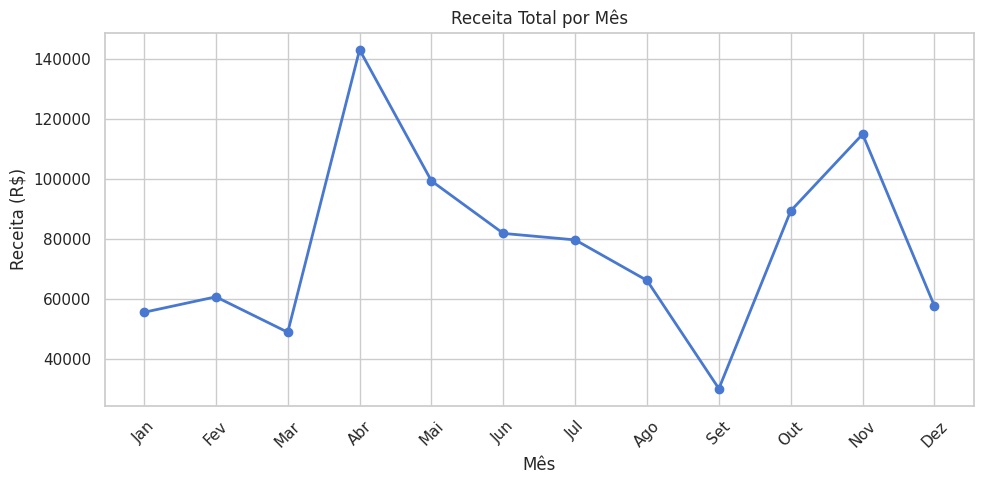

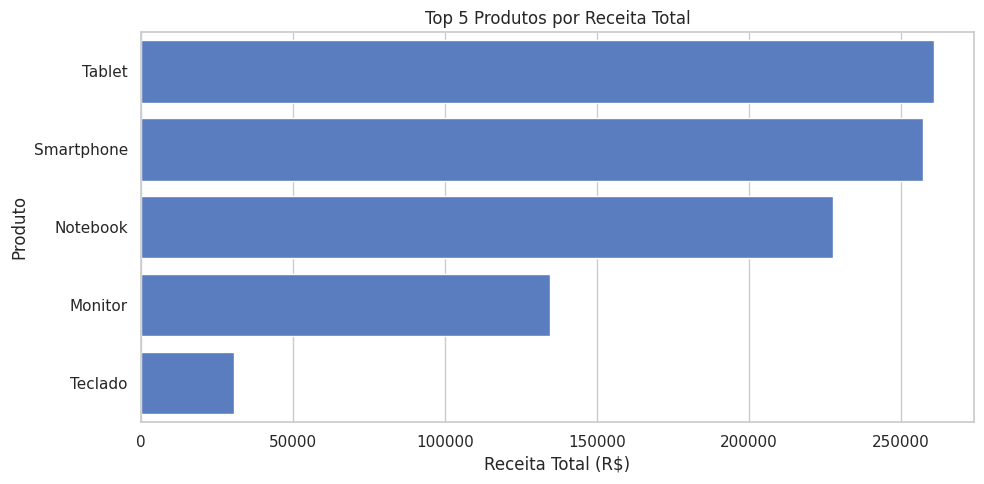

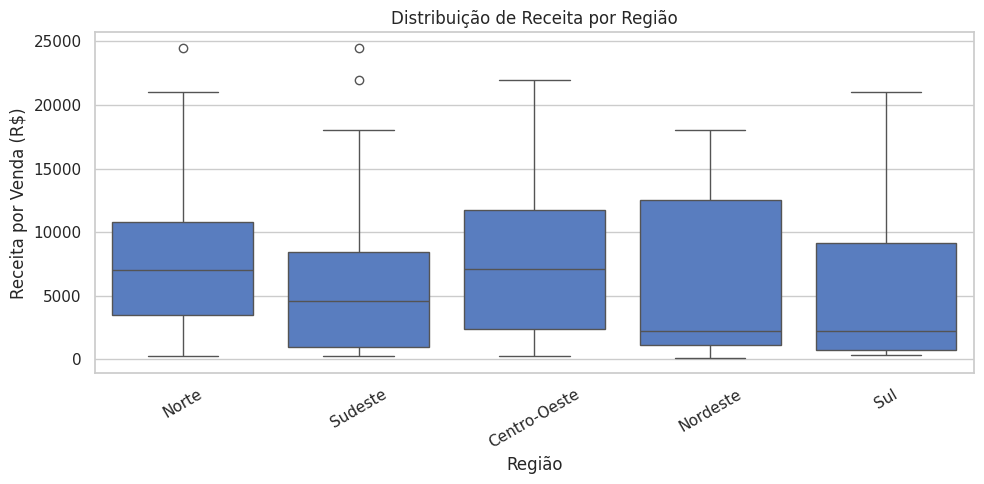

3 gráficos salvos em: outputs/graficos


In [22]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================================================
# RF09 – CRIAR VISUALIZAÇÕES COM MATPLOTLIB E SEABORN
# ===================================================================

def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """
    Gera e exporta 3 gráficos informativos em PNG:
      1. Linha  — receita total por mês (tendência ao longo do tempo)
      2. Barras — top 5 produtos por receita (ranking)
      3. Boxplot — distribuição de receita por região (dispersão e outliers)

    sns.set_theme() aplica um estilo visual global a todos os gráficos
    gerados na sessão — só precisa ser chamado uma vez.
    """
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")

    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun",
                   "Jul","Ago","Set","Out","Nov","Dez"]

    # --- Gráfico 1: Linha — Receita por Mês ---
    # Ideal para mostrar tendência e sazonalidade ao longo do tempo.
    fig, ax = plt.subplots(figsize=(10, 5))
    pm = metricas["por_mes"]
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2)
    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev, rotation=45)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show()
    plt.close()  # libera memória da figura anterior antes de criar a próxima

    # --- Gráfico 2: Barras Horizontais — Top 5 Produtos ---
    # Barras horizontais facilitam a leitura de rótulos longos (nomes de produtos).
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=metricas["top_produtos"], y="produto", x="receita_total", ax=ax)
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show()
    plt.close()

    # --- Gráfico 3: Boxplot — Distribuição de Receita por Região ---
    # O boxplot mostra mediana, quartis e outliers de cada grupo,
    # permitindo comparar não só o volume mas a variação interna
    # de cada região — informação que um gráfico de barras não entrega.
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax)
    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/dist_regiao.png", dpi=120)
    plt.show()
    plt.close()

    print(f"3 gráficos salvos em: {output_dir}")

# --- EXECUÇÃO DO RF09 ---
# Gera os gráficos passando as tabelas corretas como argumentos
gerar_visualizacoes(df, metricas)

In [23]:
import pandas as pd

# ===================================================================
# RF10 – ORGANIZAR O CÓDIGO EM FUNÇÕES REUTILIZÁVEIS
# ===================================================================

# FUNÇÕES DE ORDEM SUPERIOR
# Uma função de ordem superior é aquela que recebe outra função
# como argumento (callback) ou retorna uma função.
# Isso permite generalizar comportamentos: em vez de criar uma função
# para cada transformação possível, criamos uma que aceita qualquer
# função como parâmetro.

def aplicar_transformacao(df, coluna, funcao):
    """
    Função de ordem superior: aplica qualquer função (incluindo lambdas)
    a uma coluna do DataFrame, criando uma coluna '_transformado'.

    Parâmetros:
      df     : DataFrame de entrada
      coluna : nome da coluna a transformar
      funcao : função (ou lambda) a aplicar — o 'callback'

    Retorna uma cópia do DataFrame com a nova coluna; não modifica o original.
    """
    df = df.copy()
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)
    return df

# --- EXECUÇÃO E DEMONSTRAÇÃO DO RF10 ---

# --- Uso 1: classificar vendas por ticket com lambda ---
# lambda como callback — 2º uso distinto de lambda no projeto (1º foi em RF07)
df_demo = aplicar_transformacao(
    df,
    "receita_total",
    lambda x: "Alto" if x > 5000 else "Normal"
)
print("=== EXEMPLO: classificação por ticket ===")
print(df_demo[["receita_total", "receita_total_transformado"]].head())

# --- Uso 2: arredondar receita em milhares com lambda ---
# Demonstra que a mesma função aceita qualquer transformação
df_demo2 = aplicar_transformacao(
    df,
    "receita_total",
    lambda x: round(x / 1000, 2)
)
print("\n=== EXEMPLO: receita em milhares (R$ k) ===")
print(df_demo2[["receita_total", "receita_total_transformado"]].head())

# Nota: df_demo e df_demo2 são apenas demonstrações — df principal não é alterado.

=== EXEMPLO: classificação por ticket ===
   receita_total receita_total_transformado
0          240.0                     Normal
3          840.0                     Normal
4        10800.0                       Alto
6        14000.0                       Alto
7        13200.0                       Alto

=== EXEMPLO: receita em milhares (R$ k) ===
   receita_total  receita_total_transformado
0          240.0                        0.24
3          840.0                        0.84
4        10800.0                       10.80
6        14000.0                       14.00
7        13200.0                       13.20


In [24]:
import os
import json
import pandas as pd

# ===================================================================
# RF11 – LER E ESCREVER ARQUIVOS (CSV E JSON)
# ===================================================================

def exportar_resultados(metricas, clientes, stats):
    """
    Exporta os resultados da análise em dois formatos:
      - CSV : métricas mensais e segmentação de clientes
      - JSON: estatísticas gerais calculadas com NumPy

    Após exportar o JSON, faz a leitura de volta com json.load()
    para confirmar que o arquivo foi gravado corretamente —
    demonstrando leitura e escrita de JSON no mesmo fluxo.
    """
    os.makedirs("outputs", exist_ok=True)

    # --- Exportação CSV ---
    # encoding="utf-8-sig" adiciona um BOM (Byte Order Mark) ao arquivo.
    # Isso garante que o Excel abra o CSV com acentos corretamente.
    metricas["por_mes"].to_csv(
        "outputs/metricas_por_mes.csv", index=False, encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/metricas_por_mes.csv")

    clientes.to_csv(
        "outputs/segmentacao_clientes.csv", index=False, encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/segmentacao_clientes.csv")

    # --- Exportação JSON ---
    # ensure_ascii=False permite gravar acentos como caracteres reais (ã, é)
    # round(float(v), 2) converte para float antes de arredondar,
    # evitando comportamento inesperado com o campo 'acima_da_media' (int).
    stats_serializaveis = {k: round(float(v), 2) for k, v in stats.items()}
    caminho_json = "outputs/estatisticas_gerais.json"

    with open(caminho_json, "w", encoding="utf-8") as f:
        # indent=2 formata o JSON com recuo de 2 espaços, mais legível que uma linha só
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
    print(f"JSON exportado: {caminho_json}")

    # --- Leitura de volta para confirmar ---
    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)
    print("\nJSON lido de volta para confirmação:")
    print(json.dumps(lido, indent=2, ensure_ascii=False))

# --- EXECUÇÃO DO RF11 ---
# Passa todos os resultados coletados para a função de exportação
exportar_resultados(metricas, clientes, stats)

CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

JSON lido de volta para confirmação:
{
  "media": 6928.73,
  "mediana": 5100.0,
  "desvio_padrao": 6449.66,
  "total": 928450.0,
  "p25": 1200.0,
  "p75": 10800.0,
  "acima_da_media": 60.0
}


In [25]:
# RF12 — CONSOLIDAÇÃO FINAL
# Neste ponto do notebook, todas as etapas já foram executadas:
# Esta célula salva o dataset final em data/final/


# --- Decisão de versão ---
# Escolhemos df_v2 (outliers removidos) como base da análise final. O aluno pode optar pela v1 se quiser preservar todos os registros — ambas as versões estão salvas em “data/processed/” para consulta futura.
os.makedirs("data/final", exist_ok=True)
df.to_csv("data/final/vendas_final.csv", index=False)
print("Dataset final salvo em: data/final/vendas_final.csv")


Dataset final salvo em: data/final/vendas_final.csv
